<a href="https://colab.research.google.com/github/anishnath02/product-sales-analysis/blob/main/Sales_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Data Analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
data = pd.read_csv('sales_data_300.csv')

In [3]:
data.head()

,Order_ID,Customer_ID,Customer_Name,Gender,Age,Country,Sales_Zone,Date,Product_Category,Product_Name,Unit_Price,Quantity,Discount_Pct,Shipping_Cost,Total_Amount,Payment_Method,Order_Status
0,ORD1001,CUST0139,Ethan Joshi,Male,22.0,India,South,2025-09-01,Apparel,Shoes,65.0,1.0,0.05,0.00,61.75,PayPal,Completed
1,ORD1002,CUST0163,Sophia Garcia,Female,50.0,Germany,West,2025-01-12,Electronics,Speaker,45.0,4.0,0.25,0.00,135.00,Cash on Delivery,Completed
2,ORD1003,CUST0249,Priya Verma,Female,53.0,Canada,West,2025-08-27,Home & Kitchen,Air Fryer,85.0,1.0,0.05,9.99,90.74,Credit Card,Completed
3,ORD1004,CUST0159,Riya Gupta,Female,64.0,United States,North,2025-02-18,Beauty,Lipstick,15.0,1.0,0.10,0.00,13.50,PayPal,NaN
4,ORD1005,CUST0163,Daniel Davis,Male,37.0,India,North,2025-02-11,Home & Kitchen,Toaster,25.0,1.0,0.00,0.00,25.00,Credit Card,Completed


In [4]:
data.tail()

,Order_ID,Customer_ID,Customer_Name,Gender,Age,Country,Sales_Zone,Date,Product_Category,Product_Name,Unit_Price,Quantity,Discount_Pct,Shipping_Cost,Total_Amount,Payment_Method,Order_Status
295,ORD1296,CUST0153,Olivia Iyer,Female,27.0,United Kingdom,South,2025-01-30,Beauty,Sunscreen,16.0,2.0,0.10,9.99,38.79,Credit Card,Completed
296,ORD1297,CUST0197,Ananya Das,Female,49.0,United States,East,2025-10-22,Electronics,Speaker,45.0,1.0,0.15,0.00,38.25,Credit Card,Completed
297,ORD1298,CUST0154,Kabir Patel,Male,60.0,United Kingdom,East,2025-04-18,Apparel,T-Shirt,20.0,2.0,0.00,0.00,40.00,Cash on Delivery,Completed
298,ORD1299,CUST0210,Amelia Smith,Female,47.0,India,West,2025-10-08,Electronics,Phone,650.0,2.0,0.15,9.99,1114.99,Credit Card,Completed
299,ORD1300,CUST0249,Liam Sharma,NaN,56.0,United Kingdom,North,2025-05-08,Beauty,Face Cream,22.0,1.0,0.10,0.00,19.80,PayPal,Completed


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          300 non-null    object 
 1   Customer_ID       300 non-null    object 
 2   Customer_Name     295 non-null    object 
 3   Gender            297 non-null    object 
 4   Age               296 non-null    float64
 5   Country           297 non-null    object 
 6   Sales_Zone        293 non-null    object 
 7   Date              300 non-null    object 
 8   Product_Category  300 non-null    object 
 9   Product_Name      300 non-null    object 
 10  Unit_Price        297 non-null    float64
 11  Quantity          295 non-null    float64
 12  Discount_Pct      297 non-null    float64
 13  Shipping_Cost     296 non-null    float64
 14  Total_Amount      300 non-null    float64
 15  Payment_Method    295 non-null    object 
 16  Order_Status      297 non-null    object 
dt

## **Data Cleaning**

In [6]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Discount_Pct', 'Shipping_Cost', 'Total_Amount',
       'Payment_Method', 'Order_Status'],
      dtype='object')

In [7]:
#remove unwanted columns
data.drop(['Discount_Pct', 'Shipping_Cost', 'Total_Amount'], axis=1, inplace=True)

In [8]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status'],
      dtype='object')

In [9]:
pd.isnull(data)

,Order_ID,Customer_ID,Customer_Name,Gender,Age,Country,Sales_Zone,Date,Product_Category,Product_Name,Unit_Price,Quantity,Payment_Method,Order_Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
pd.isnull(data).sum()

,0
Order_ID,0
Customer_ID,0
Customer_Name,5
Gender,3
Age,4
Country,3
Sales_Zone,7
Date,0
Product_Category,0
Product_Name,0


In [11]:
data.shape

(300, 14)

In [12]:
# drop null values
data.dropna(inplace=True)

In [13]:
data.shape

(266, 14)

In [14]:
pd.isnull(data).sum()

,0
Order_ID,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
Country,0
Sales_Zone,0
Date,0
Product_Category,0
Product_Name,0


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          266 non-null    object 
 1   Customer_ID       266 non-null    object 
 2   Customer_Name     266 non-null    object 
 3   Gender            266 non-null    object 
 4   Age               266 non-null    float64
 5   Country           266 non-null    object 
 6   Sales_Zone        266 non-null    object 
 7   Date              266 non-null    object 
 8   Product_Category  266 non-null    object 
 9   Product_Name      266 non-null    object 
 10  Unit_Price        266 non-null    float64
 11  Quantity          266 non-null    float64
 12  Payment_Method    266 non-null    object 
 13  Order_Status      266 non-null    object 
dtypes: float64(3), object(11)
memory usage: 31.2+ KB


In [16]:
# change the data type of 'Quantity'
data['Quantity'] = data['Quantity'].astype('int')

In [17]:
data['Quantity'].dtype

dtype('int64')

In [18]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status'],
      dtype='object')

In [19]:
# rename column
data.rename(columns={
    'Customer_ID':'ID'
}, inplace=True)

In [20]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status'],
      dtype='object')

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          266 non-null    object 
 1   ID                266 non-null    object 
 2   Customer_Name     266 non-null    object 
 3   Gender            266 non-null    object 
 4   Age               266 non-null    float64
 5   Country           266 non-null    object 
 6   Sales_Zone        266 non-null    object 
 7   Date              266 non-null    object 
 8   Product_Category  266 non-null    object 
 9   Product_Name      266 non-null    object 
 10  Unit_Price        266 non-null    float64
 11  Quantity          266 non-null    int64  
 12  Payment_Method    266 non-null    object 
 13  Order_Status      266 non-null    object 
dtypes: float64(2), int64(1), object(11)
memory usage: 31.2+ KB


In [22]:
# change the data type of 'Age'
data['Age'] = data['Age'].astype('int')

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          266 non-null    object 
 1   ID                266 non-null    object 
 2   Customer_Name     266 non-null    object 
 3   Gender            266 non-null    object 
 4   Age               266 non-null    int64  
 5   Country           266 non-null    object 
 6   Sales_Zone        266 non-null    object 
 7   Date              266 non-null    object 
 8   Product_Category  266 non-null    object 
 9   Product_Name      266 non-null    object 
 10  Unit_Price        266 non-null    float64
 11  Quantity          266 non-null    int64  
 12  Payment_Method    266 non-null    object 
 13  Order_Status      266 non-null    object 
dtypes: float64(1), int64(2), object(11)
memory usage: 31.2+ KB


## **EDA (Exploratory Data Analysis)**

### **Gender**

In [24]:
data.describe()

,Age,Unit_Price,Quantity
count,266.000000,266.000000,266.000000
mean,44.139098,179.018797,1.947368
std,14.455377,262.730933,1.148031
min,18.000000,12.000000,1.000000
25%,31.250000,25.000000,1.000000
50%,46.000000,60.000000,2.000000
75%,57.000000,110.000000,3.000000
max,67.000000,850.000000,5.000000


In [25]:
data[['Unit_Price', 'Quantity']].describe()

,Unit_Price,Quantity
count,266.000000,266.000000
mean,179.018797,1.947368
std,262.730933,1.148031
min,12.000000,1.000000
25%,25.000000,1.000000
50%,60.000000,2.000000
75%,110.000000,3.000000
max,850.000000,5.000000


In [26]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status'],
      dtype='object')

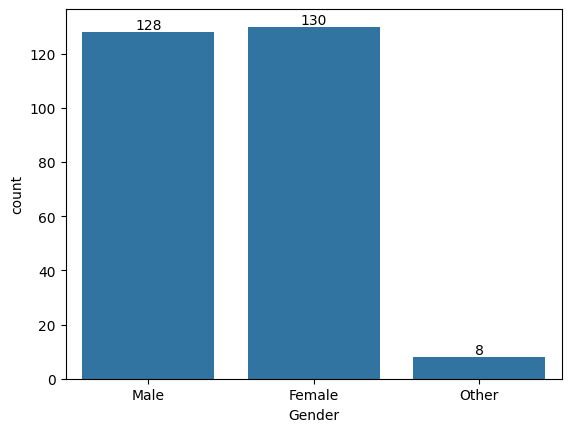

In [27]:
gd = sns.countplot(x = 'Gender', data=data)

for bars in gd.containers:
  gd.bar_label(bars)

In [28]:
data.groupby(['Gender'], as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False)

,Gender,Quantity
0,Female,258
1,Male,245
2,Other,15


<Axes: xlabel='Gender', ylabel='Quantity'>

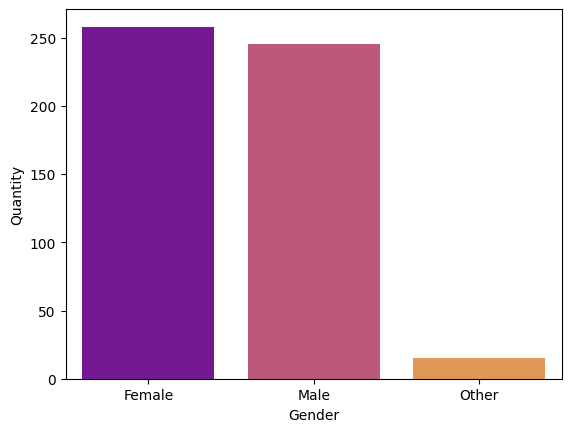

In [29]:
sales_gen = data.groupby(['Gender'], as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False)

sns.barplot(x = 'Gender', y = 'Quantity', data = sales_gen, hue='Gender', palette='plasma')

### From the above graph we can determine that the number of Female buyers is slightly higher than the Male buyers, lowest is others

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          266 non-null    object 
 1   ID                266 non-null    object 
 2   Customer_Name     266 non-null    object 
 3   Gender            266 non-null    object 
 4   Age               266 non-null    int64  
 5   Country           266 non-null    object 
 6   Sales_Zone        266 non-null    object 
 7   Date              266 non-null    object 
 8   Product_Category  266 non-null    object 
 9   Product_Name      266 non-null    object 
 10  Unit_Price        266 non-null    float64
 11  Quantity          266 non-null    int64  
 12  Payment_Method    266 non-null    object 
 13  Order_Status      266 non-null    object 
dtypes: float64(1), int64(2), object(11)
memory usage: 31.2+ KB


In [31]:
# create new column
data['Total_Price'] = data['Quantity'] * data['Unit_Price']

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          266 non-null    object 
 1   ID                266 non-null    object 
 2   Customer_Name     266 non-null    object 
 3   Gender            266 non-null    object 
 4   Age               266 non-null    int64  
 5   Country           266 non-null    object 
 6   Sales_Zone        266 non-null    object 
 7   Date              266 non-null    object 
 8   Product_Category  266 non-null    object 
 9   Product_Name      266 non-null    object 
 10  Unit_Price        266 non-null    float64
 11  Quantity          266 non-null    int64  
 12  Payment_Method    266 non-null    object 
 13  Order_Status      266 non-null    object 
 14  Total_Price       266 non-null    float64
dtypes: float64(2), int64(2), object(11)
memory usage: 33.2+ KB


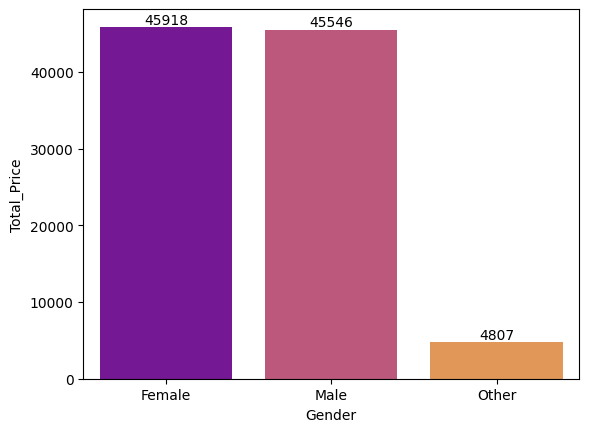

In [33]:
total_sales_gen = data.groupby(['Gender'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)

tsg = sns.barplot(x = 'Gender', y = 'Total_Price', data = total_sales_gen, hue='Gender', palette='plasma')

for bars in tsg.containers:
  tsg.bar_label(bars)

### Male and Female has appprox same purchasing power

### **Age**

In [34]:
bins = [18, 30, 40, 50, 60, 70]

labels = ['18-30', '31-40', '41-50', '51-60', '61-70']

data['Age_Group'] = pd.cut(
    data['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266 entries, 0 to 298
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Order_ID          266 non-null    object  
 1   ID                266 non-null    object  
 2   Customer_Name     266 non-null    object  
 3   Gender            266 non-null    object  
 4   Age               266 non-null    int64   
 5   Country           266 non-null    object  
 6   Sales_Zone        266 non-null    object  
 7   Date              266 non-null    object  
 8   Product_Category  266 non-null    object  
 9   Product_Name      266 non-null    object  
 10  Unit_Price        266 non-null    float64 
 11  Quantity          266 non-null    int64   
 12  Payment_Method    266 non-null    object  
 13  Order_Status      266 non-null    object  
 14  Total_Price       266 non-null    float64 
 15  Age_Group         266 non-null    category
dtypes: category(1), float64(2), int

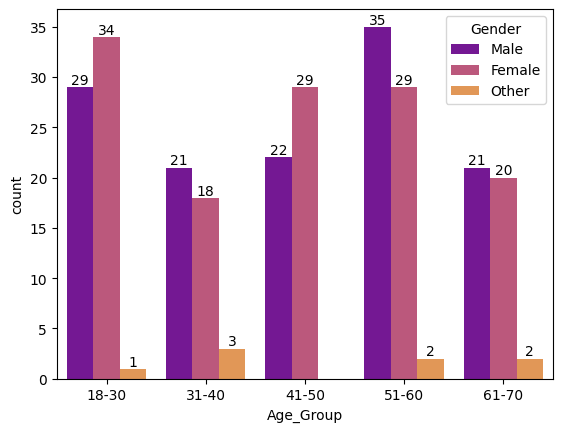

In [36]:
ax = sns.countplot(x = 'Age_Group', data=data, hue='Gender', palette='plasma')

for bars in ax.containers:
  ax.bar_label(bars)

/tmp/ipykernel_2920/3544782538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_age = data.groupby(['Age_Group'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)


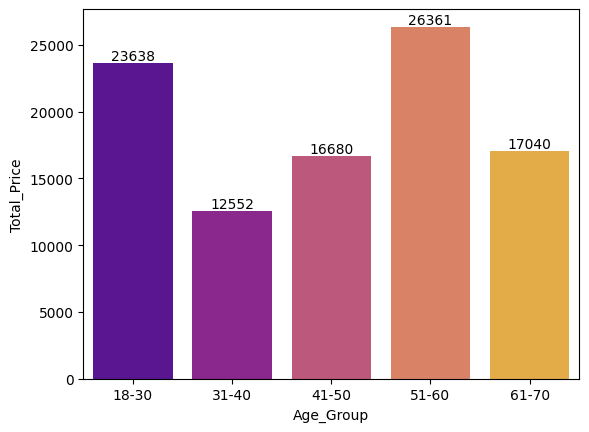

In [37]:
sales_age = data.groupby(['Age_Group'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)

agp = sns.barplot(x = 'Age_Group', y = 'Total_Price', data = sales_age, hue='Age_Group', palette='plasma')

for bars in agp.containers:
  agp.bar_label(bars)

### From the above graph we can see most of the buyers are in between 18-30 and 51-60, mosty female

### **Country**

In [38]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status', 'Total_Price',
       'Age_Group'],
      dtype='object')

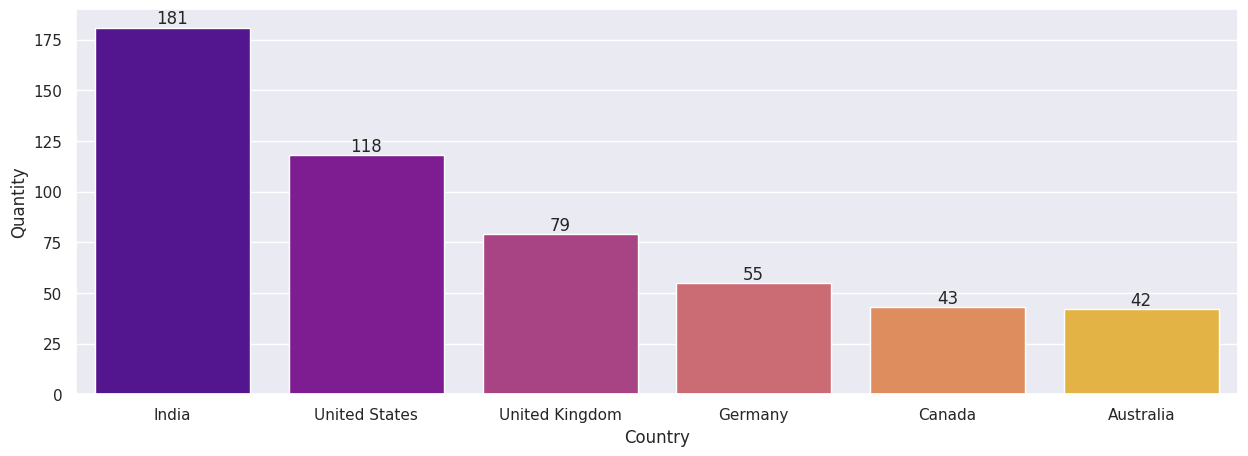

In [39]:
# total number of orders from top 10 countries
country_sales = data.groupby(['Country'], as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False)

sns.set(rc={'figure.figsize':(15,5)})
cs = sns.barplot(x = 'Country', y = 'Quantity', data = country_sales, hue='Country', palette='plasma')

for bars in cs.containers:
  cs.bar_label(bars)

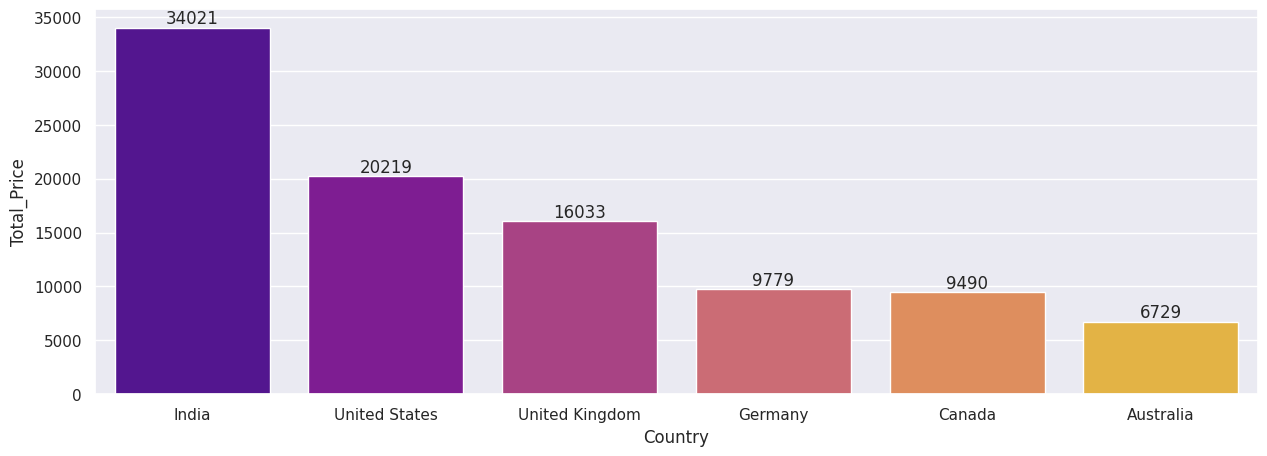

In [40]:
# total amount from top 10 countries
country_Tsales = data.groupby(['Country'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)

sns.set(rc={'figure.figsize':(15,5)})
ct = sns.barplot(x = 'Country', y = 'Total_Price', data = country_Tsales, hue='Country', palette='plasma')

for bars in ct.containers:
  ct.bar_label(bars)

### Most of the orders from India, United States, United Kingdom

### **Order Status**

In [41]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status', 'Total_Price',
       'Age_Group'],
      dtype='object')

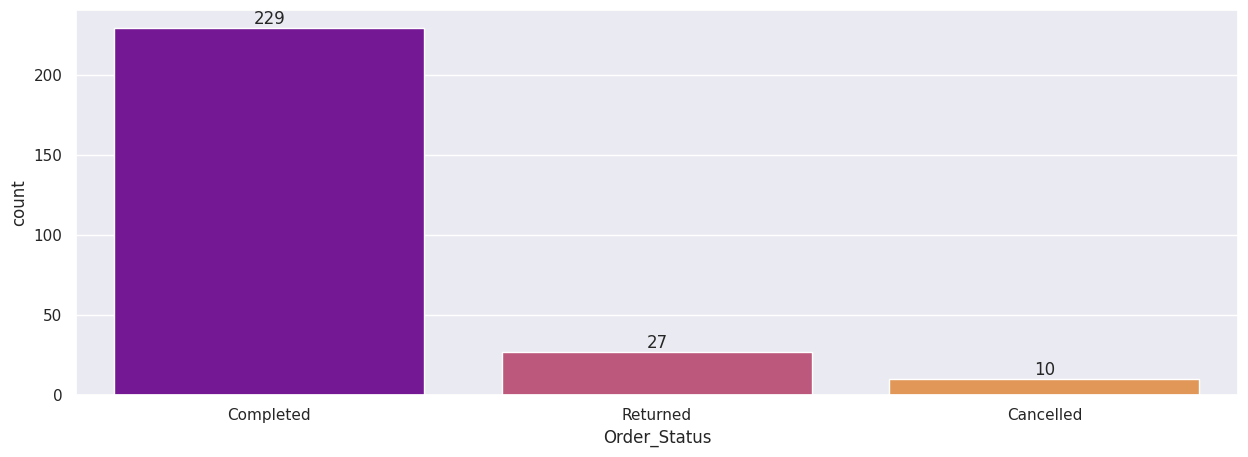

In [42]:
os = sns.countplot(x = 'Order_Status', data=data, hue='Order_Status', palette='plasma')

for bars in os.containers:
  os.bar_label(bars)

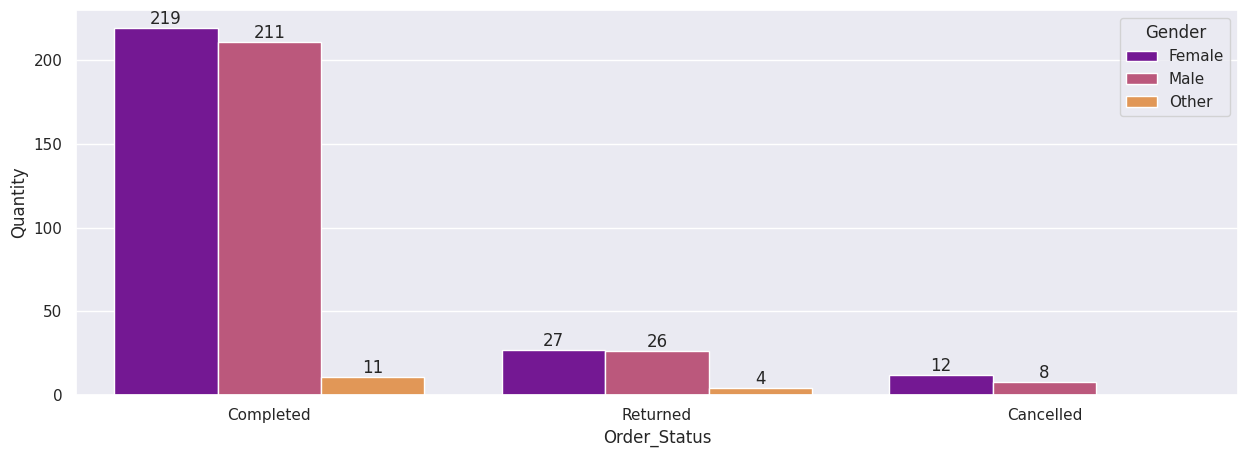

In [43]:
status_sales = data.groupby(['Order_Status', 'Gender'], as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False)

ss = sns.barplot(x = 'Order_Status', y = 'Quantity', data = status_sales, hue='Gender', palette='plasma')

for bars in ss.containers:
  ss.bar_label(bars)

### From the above graph we can say that order status is mostly completed and purchasing power of females is slightly higher than mens

### **Sales Zone**

In [44]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status', 'Total_Price',
       'Age_Group'],
      dtype='object')

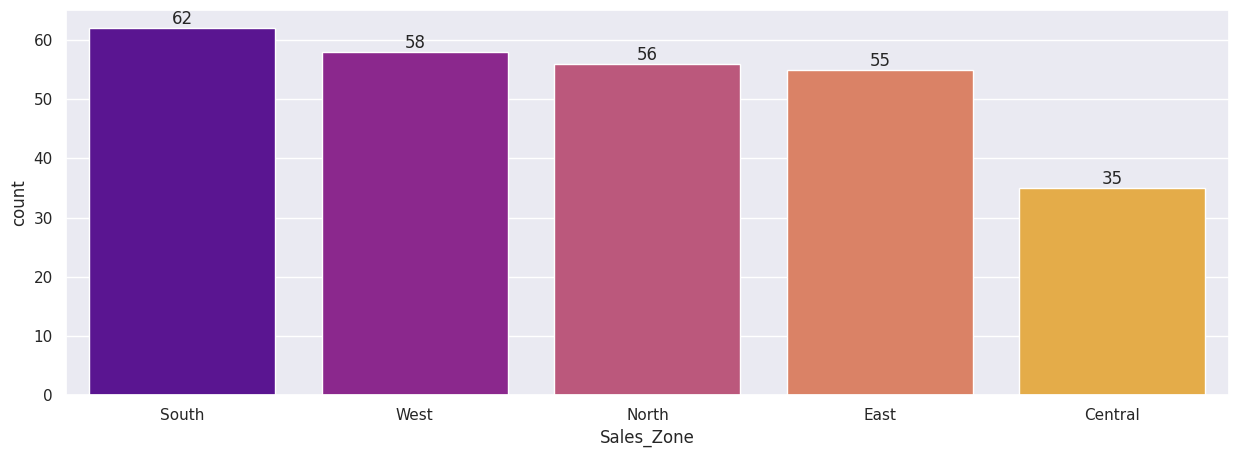

In [45]:
sz = sns.countplot(x = 'Sales_Zone', data=data, hue='Sales_Zone', palette='plasma')

for bars in sz.containers:
  sz.bar_label(bars)

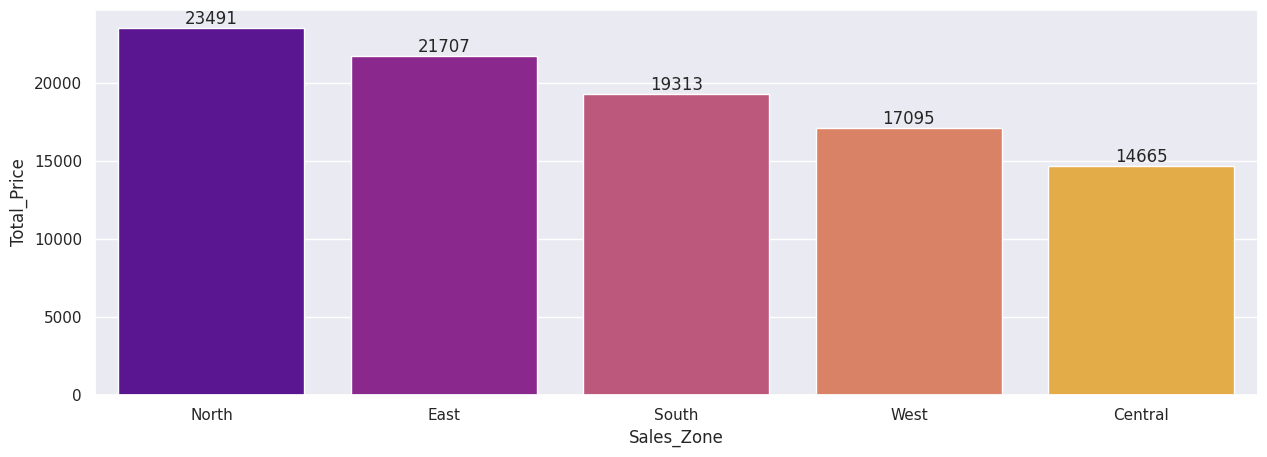

In [46]:
sales_zonal = data.groupby(['Sales_Zone'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)

sa = sns.barplot(x = 'Sales_Zone', y = 'Total_Price', data = sales_zonal, hue='Sales_Zone', palette='plasma')

for bars in sa.containers:
  sa.bar_label(bars)

### Most of the buyers from North, East then South zones - Buyers from the North zone has the most purchasing power

### **Product Category**

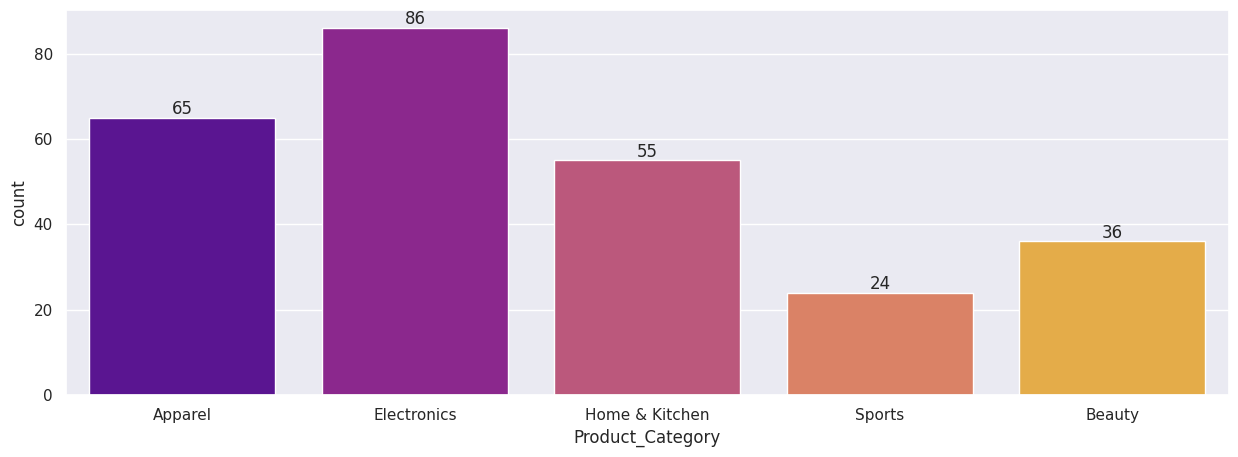

In [47]:
pc = sns.countplot(x = 'Product_Category', data=data, hue='Product_Category', palette='plasma')

for bars in pc.containers:
  pc.bar_label(bars)

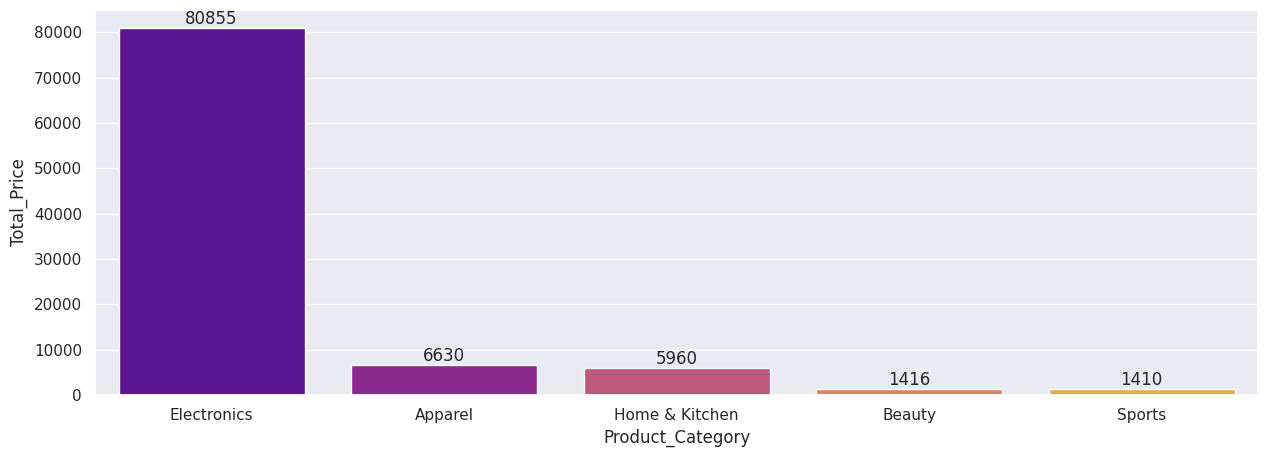

In [48]:
sales_state = data.groupby(['Product_Category'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False)

pc = sns.barplot(x = 'Product_Category', y = 'Total_Price', data = sales_state, hue='Product_Category', palette='plasma')

for bars in pc.containers:
  pc.bar_label(bars)

### Most sold products are from Electronics, Apparel, Home & Kitchen - Electronics category generates Most sold amount by a big margin

### **Product Name**

In [49]:
data.columns

Index(['Order_ID', 'ID', 'Customer_Name', 'Gender', 'Age', 'Country',
       'Sales_Zone', 'Date', 'Product_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Payment_Method', 'Order_Status', 'Total_Price',
       'Age_Group'],
      dtype='object')

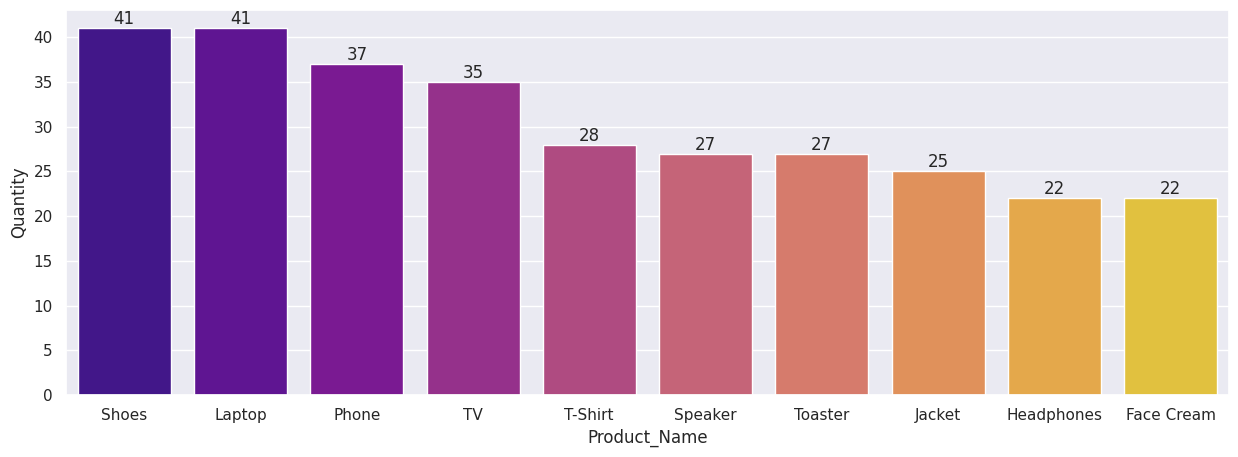

In [50]:
sales_state = data.groupby(['Product_Name'], as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False).head(10)

pn = sns.barplot(x = 'Product_Name', y = 'Quantity', data = sales_state, hue='Product_Name', palette='plasma')

for bars in pn.containers:
  pn.bar_label(bars)

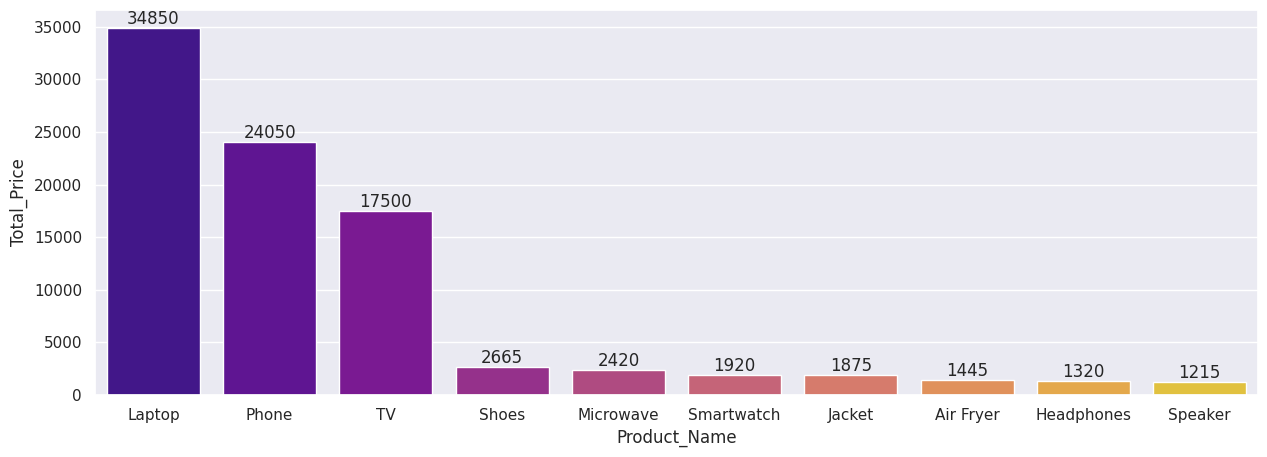

In [51]:
sales_state = data.groupby(['Product_Name'], as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False).head(10)

pn = sns.barplot(x = 'Product_Name', y = 'Total_Price', data = sales_state, hue='Product_Name', palette='plasma')

for bars in pn.containers:
  pn.bar_label(bars)

<Axes: xlabel='Product_Name'>

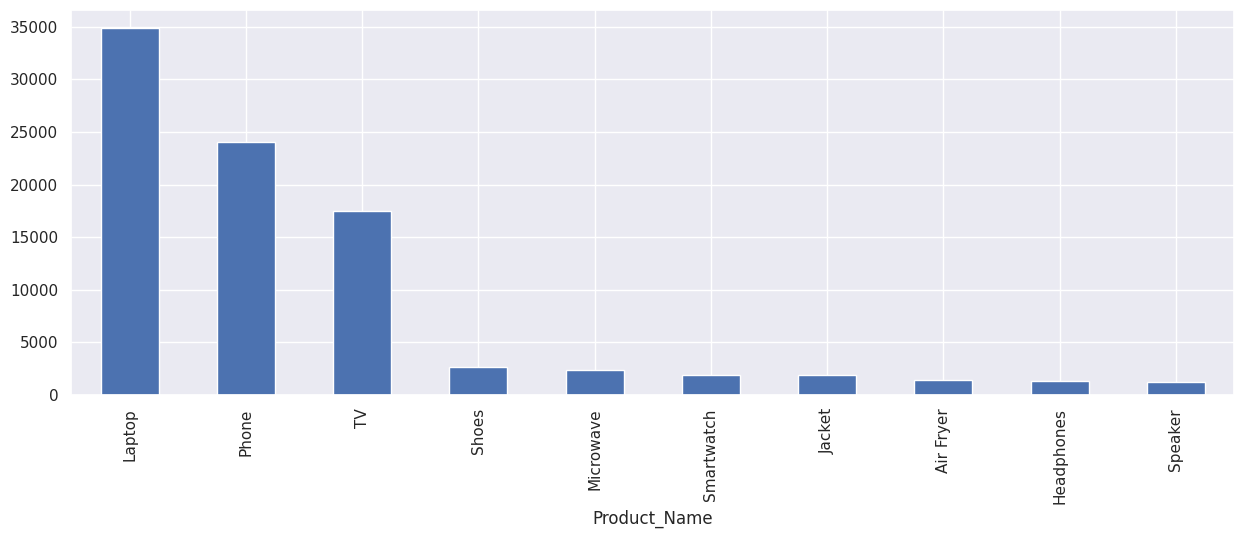

In [52]:
data.groupby('Product_Name')['Total_Price'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

### Shoes and Laptop are the best selling products, but Laptop and Phones generated most revenew.

## **Conclusion**

### **Sales Analysis**
1) Purchasing power of male and female is almost same, no. of female buyers are more.
2) Most of the **Female** buyers are aged between **18-30** and most of the **Male** buyers are aged between **51-60**.
3) Buyers are mostlt from **India, USA and UK**, ( Zones - **North, East, South**).
4) Most of the purchases are completed.
5) Most of the products are from **Electronics, Apprarel and Home & Kitchen** - **Electronics Category** generated large amount of money.
6) Best Selling products are **Shoes** and **Laptop** - Most of the revenue generated by selling **Laptop** and **Phones**.